# Analytics for Value Investing - Group Project
## S&P 500 Ex-Financials Quantitative Backtest (2010–2025)

**Team Members:**

<div style="display: inline-block">

| Name | Student ID | Main Role |
| :-------- | :-------- | :-------- |
| Kathryn Chan Hui | 01532587 | Development |
| Ng Hock Wah | 01513633 | Development |
| Liu Yi-Yi | 01548034 | Report |
| Liu Zhemin | 01525938 | Report |
| Zhang Tianrui | 01526062 | Slides |
| Ma Sunan | 01528539 | Slides |

</div>

**Course:** ACCT 656 - Analytics for Value Investing<br>
**Submission Date:** 19 June 2026

### Project Objective
To develop an accounting-based investment strategy that identifies high-quality value stocks using financial statement signals related to value, profitability, quality, safety, and investment discipline.

### Rules & Constraints
* **Universe:** S&P 500 companies, strictly excluding all banks and financial institutions.
* **Time Horizon:** 16 years of data, ending no earlier than 2025 (2010–2025).
* **Data Frequency:** Strictly limited to monthly stock price/return data and annual financial/accounting data.

In [2]:
## IMPORT LIBRARIES

# General libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import time
import warnings
# Financial libraries
import yfinance as yf

# Suppress warnings for cleaner submission output
warnings.filterwarnings('ignore')
# Set plotting aesthetics for report-ready charts
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## LOAD DATA

print("Loading project datasets...")
snp_raw = pd.read_csv("data/compustat_fundamental_annual.csv") # raw data from Compustat
sp500 = pd.read_csv("data/constituents.csv") # data of S&P 500 constituents

Loading project datasets...


### 1. Data Preparation
Before conducting financial ratio analysis, the raw Compustat data has to be processed.
1. `costat` column was removed as there is only 1 unique value
2. Entries of `USD` currency (`curcd`) were kept, `CAD` entries were removed to prevent FX conversion issues and restrict the universe to the U.S. metrics
3. `datafmt`, `indfmt`, `consol` columns were removed as they are redundant database identifiers
4. `fyr` column was removed as we can calculate the fiscal year-end date using `datadate` column

In [3]:
# snp_raw["sic"].value_counts()

# --------------------------------------------------
# 1.1 Clean up raw Compustat data
# --------------------------------------------------

# Drop costat column since it is not relevant to our analysis
snp_raw.drop("costat", inplace=True, axis=1)
# Drop CAD since we dont want to convert it to USD
snp_raw.drop(snp_raw[snp_raw["curcd"] == "CAD"].index, inplace=True, axis=0)
# Drop curcd column since we only have USD data
snp_raw.drop("curcd", inplace=True, axis=1)
# Drop datafmt, indfmt and consol columns since they are not relevant to our analysis
snp_raw.drop(["datafmt", "indfmt", "consol"], inplace=True, axis=1)
# Drop fyr column since we can calculate fiscal year end date using datadate column
snp_raw.drop("fyr", inplace=True, axis=1)
snp_raw.head()

,gvkey,datadate,conm,tic,cik,naics,sic,at,ceq,che,...,ebit,ebitda,gp,ni,revt,sale,capx,oancf,csho,prcc_f
0,1004,31/5/2009,AAR CORP,AIR,1750.0,423860.0,5080,1377.511,656.895,112.505,...,125.529,166.080,313.299,78.651,1423.976,1423.976,27.535,64.451,38.884,14.70
1,1004,31/5/2010,AAR CORP,AIR,1750.0,423860.0,5080,1501.042,746.906,79.370,...,95.415,134.345,286.249,44.628,1352.151,1352.151,28.855,153.156,39.484,19.70
2,1004,31/5/2011,AAR CORP,AIR,1750.0,423860.0,5080,1703.727,835.845,57.433,...,137.016,196.312,367.711,69.826,1775.782,1775.782,124.879,108.598,39.781,26.39
3,1004,31/5/2012,AAR CORP,AIR,1750.0,423860.0,5080,2195.653,864.649,67.720,...,142.360,222.693,412.090,67.723,2074.498,2074.498,91.218,94.217,40.273,12.05
4,1004,31/5/2013,AAR CORP,AIR,1750.0,423860.0,5080,2136.900,918.600,75.300,...,136.600,245.200,452.600,55.000,2167.100,2167.100,37.600,162.900,39.382,20.06


As bank and financial institutions have different financial statement structure, we will drop them from our analysis. This is done by analysing the data of S&P 500 constituents to exclude GIC Sectors that are of value `Financials`. Following this, any banking-related companies using sub-industry keywords are removed.

It is noted that the number of companies reduced from 503 to 427 companies.

In [4]:
sp500.head() # check the first few rows

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [5]:
# --------------------------------------------------
# 1.2 Remove companies under Financials sector
# --------------------------------------------------

sp500_nonfin = sp500[
    sp500["GICS Sector"] != "Financials"
].copy()

print("Original number of S&P 500 companies:", len(sp500))
print("After removing Financials:", len(sp500_nonfin))

Original number of S&P 500 companies: 503
After removing Financials: 427


In [6]:
# --------------------------------------------------
# 1.2 Remove banking-related companies using sub-industry keywords
# --------------------------------------------------

banking_keywords = [
    "bank",
    "banks",
    "banking",
    "financial",
    "insurance",
    "capital markets",
    "mortgage",
    "consumer finance",
    "diversified financial",
    "asset management",
    "investment banking",
    "brokerage"
]

pattern = "|".join(banking_keywords)
sp500_nonfin = sp500_nonfin[
    ~sp500_nonfin["GICS Sub-Industry"]
    .str.lower()
    .str.contains(pattern, na=False)
].copy()

print("After removing Financials and banking-related firms:", len(sp500_nonfin))

After removing Financials and banking-related firms: 427


We now create a Yahoo Finance-compatible ticker that cleans the symbol provided to create a standardised ticker that will be used to filter the data in `snp_raw`.

In [7]:
# --------------------------------------------------
# 1.3 Create Yahoo Finance-compatible ticker
# --------------------------------------------------

sp500_nonfin["ticker_yahoo"] = (
    sp500_nonfin["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(".", "-", regex=False)
)

sp500_nonfin[["Symbol", "ticker_yahoo", "Security", "GICS Sector", "GICS Sub-Industry"]].head()

,Symbol,ticker_yahoo,Security,GICS Sector,GICS Sub-Industry
0,MMM,MMM,3M,Industrials,Industrial Conglomerates
1,AOS,AOS,A. O. Smith,Industrials,Building Products
2,ABT,ABT,Abbott Laboratories,Health Care,Health Care Equipment
3,ABBV,ABBV,AbbVie,Health Care,Biotechnology
4,ACN,ACN,Accenture,Information Technology,IT Consulting & Other Services


Non-Financial tickers are now merged with `snp_raw` to keep only non-financial company entries

In [8]:
# --------------------------------------------------
# 1.4 Merge S&P 500 data with Yahoo Finance-compatible tickers
# --------------------------------------------------

snp500_overall = pd.merge(snp_raw, sp500_nonfin, left_on="tic", right_on="ticker_yahoo", how="inner")
snp500_overall.drop(["tic", "Symbol"], inplace=True, axis=1)
snp500_overall.head()

,gvkey,datadate,conm,cik,naics,sic,at,ceq,che,dlc,...,csho,prcc_f,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,ticker_yahoo
0,1075,31/12/2009,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,11808.155,3316.109,145.378,431.408,...,101.435,36.58,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW
1,1075,31/12/2010,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,12362.703,3683.327,110.188,648.479,...,108.770,41.45,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW
2,1075,31/12/2011,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,13111.018,3821.850,33.583,477.435,...,109.246,48.18,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW
3,1075,31/12/2012,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,13379.615,3972.806,26.202,215.003,...,109.743,50.98,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW
4,1075,31/12/2013,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,13508.686,4194.470,9.526,693.549,...,110.182,52.92,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW


In [9]:
# Store merged data to understand the data content
snp500_overall.to_csv("data/snp500_merged.csv", index=False)

### 2. Data Cleaning
Before working with the data to calculate financial ratios, a quick review of the contents of the S&P 500 raw data from Compustat showed some entries having no financial data. If more than 25% of a row is missing, the firm-year observation is likely too incomplete to be reliable. To confirm the removal, this is done on a small sample of data where known entries are to be omitted.

After confirming this is the threshold to be used, the removal will be done on the whole dataset.

In [10]:
# --------------------------------------------------
# 2.1 Testing removal of entries with more than 25% missing values
# --------------------------------------------------

# Checking specific rows to confirm missing values are handled correctly
copy = snp500_overall.iloc[6840:6845].copy()
## we want to remove rows with more than 25% missing values, so we check rows around the 25% threshold
cleaned = copy[copy.isna().mean(axis=1) <= 0.25]
# Printed copy and cleaned to confirm that the correct rows are removed

In [11]:
# --------------------------------------------------
# 2.2 Conduct actual removal of entries with more than 25% missing values
# --------------------------------------------------

snp500_overall_cleaned = snp500_overall[snp500_overall.isna().mean(axis=1) <= 0.25]
print("Original number of rows:", len(snp500_overall))
print("Number of rows after cleaning:", len(snp500_overall_cleaned))
print("Number of rows removed:", len(snp500_overall) - len(snp500_overall_cleaned))

Original number of rows: 6878
Number of rows after cleaning: 6846
Number of rows removed: 32


Note: cross checked with excel, all 32 rows of empty data was removed

In [12]:
# Store cleaned data for analysis
snp500_overall_cleaned.to_csv("data/snp500_cleaned.csv", index=False)

### 3. Downloading Yahoo monthly stock returns
To evaluate the portfolio performance, the `yfinance` API is used to download monthly adjusted closing prices from 2009 to 2025 for the non-financial S&P 500 universe - established in Section 2.

*Note: Any failed downloads (e.g., delisted tickers like FDXF) would be tracked and isolated for removal.*

In [13]:
# Load the cleaned S&P 500 data for analysis

snp500_cleaned = pd.read_csv("data/snp500_cleaned.csv")

tickers = (
    snp500_cleaned["ticker_yahoo"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .unique()
    .tolist()
)

tickers = sorted(tickers)
print("Number of tickers:", len(tickers))

Number of tickers: 423


To calculate monthly stock returns, the filtered universe is iterated through to download historical pricing data using the `yfinance` API. The adjusted closing price is extracted with `auto_adjust=True`. This ensures that subsequent return calculations (using `pct_change()`) is accounted for. Any failed downloads due to delisted tickers are logged and excluded.

In [14]:
# --------------------------------------------------
# 3.1 Download monthly adjusted prices from Yahoo Finance
# --------------------------------------------------

all_monthly_data = []
failed_tickers = []

for i, ticker in enumerate(tickers, start=1):
    try:
        print(f"Downloading {i}/{len(tickers)}: {ticker}")

        data = yf.download(
            ticker,
            start="2009-01-01",
            end="2025-12-31",
            interval="1mo",
            auto_adjust=True,
            progress=False,
            multi_level_index=False
        )

        if data.empty:
            print(f"No data found for: {ticker}")
            failed_tickers.append(ticker)
            continue

        # Reset index so Date becomes a column
        data = data.reset_index()
        # Keep only date and adjusted close price
        temp = data[["Date", "Close"]].copy()

        temp["ticker_yahoo"] = ticker
        temp = temp.rename(columns={
            "Date": "month",
            "Close": "adjusted_close"
        })

        temp["month"] = pd.to_datetime(temp["month"])
        # Calculate monthly return ticker by ticker
        temp["monthly_return"] = temp["adjusted_close"].pct_change()

        all_monthly_data.append(
            temp[["ticker_yahoo", "month", "adjusted_close", "monthly_return"]]
        )

        time.sleep(0.3)

    except Exception as e:
        print(f"Failed to download {ticker}: {e}")
        failed_tickers.append(ticker)

$FDXF: possibly delisted; no price data found  (1mo 2009-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1230786000, endDate = 1767157200")

1 Failed download:
['FDXF']: possibly delisted; no price data found  (1mo 2009-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1230786000, endDate = 1767157200")


No data found for: FDXF


The monthly stock returns data are now concatenatedinto a single consolidated dataframe and sorted chronologically by company. To maintain data integrity for the remainder of the backtest, the cleaned monthly stock data and the list of failed downloads (e.g.: delisted tickers) into separate CSV files for further analysis and cross-referencing.

In [15]:
# --------------------------------------------------
# 3.2 Combine all downloaded monthly data
# --------------------------------------------------

monthly_stock_data = pd.concat(all_monthly_data, ignore_index=True)

monthly_stock_data = monthly_stock_data.sort_values(
    ["ticker_yahoo", "month"]
).reset_index(drop=True)

# Save clean monthly return file
monthly_stock_data.to_csv("data/yahoo_monthly_stock_returns_clean.csv", index=False)

# Save failed tickers
failed_df = pd.DataFrame({"failed_ticker": failed_tickers})
failed_df.to_csv("data/failed_yahoo_tickers.csv", index=False)

print("Monthly stock return file saved as: data/yahoo_monthly_stock_returns_clean.csv")
print("Failed ticker file saved as: data/failed_yahoo_tickers.csv")
print("Number of failed tickers:", len(failed_tickers))

Monthly stock return file saved as: data/yahoo_monthly_stock_returns_clean.csv
Failed ticker file saved as: data/failed_yahoo_tickers.csv
Number of failed tickers: 1


To ensure the integrity of the downloaded Yahoo Finance pricing data before constructing signals, a final review of the consolidated data is conducted. The following metrics are displayed:
- **Shape of data**: To note the total number of monthly-firm observations
- **Date range**: To verify the timeframe correctly spans the specified 2009 - 2025 horizon
- **Columns**: To verify the presence of required variables (`adjusted_close` and `monthly_return`) for upcoming analysis
- **Sample**: A preview of the first 20 chronological observations

In [16]:
# --------------------------------------------------
# 3.3 Validation checks
# --------------------------------------------------

print("Shape:", monthly_stock_data.shape)

print(f"\nDate range: {monthly_stock_data['month'].min()} to {monthly_stock_data['month'].max()}")
print(f"Number of tickers downloaded: {monthly_stock_data['ticker_yahoo'].nunique()}")
print(f"Columns: {monthly_stock_data.columns.tolist()}")

print("\nSample:")
monthly_stock_data.head(20)

Shape: (80285, 4)

Date range: 2009-01-01 00:00:00 to 2025-12-01 00:00:00
Number of tickers downloaded: 422
Columns: ['ticker_yahoo', 'month', 'adjusted_close', 'monthly_return']

Sample:


,ticker_yahoo,month,adjusted_close,monthly_return
0,A,2009-01-01,11.443534,NaN
1,A,2009-02-01,8.778862,-0.232854
2,A,2009-03-01,9.728269,0.108147
3,A,2009-04-01,11.557462,0.188029
4,A,2009-05-01,11.538477,-0.001643
5,A,2009-06-01,12.854988,0.114097
6,A,2009-07-01,14.696841,0.143279
7,A,2009-08-01,16.253864,0.105943
8,A,2009-09-01,17.614687,0.083723
9,A,2009-10-01,15.658908,-0.111031


### 4. Aligning S&P 500 Universe (Removing failed tickers)
Before constructing financial signals, consistency should be established between the annual accounting data (Compustat) and the available monthly stock closing pricing data (Yahoo Finance).

By using the `failed_yahoo_tickers.csv` log, we can identify companies that lack pricing data (e.g.: delisted ticker `FDXF`) and remove their corresponding firm-year observations from the Compustat data.

The final universe has 422 tradeable S&P 500 companies.

In [17]:
# --------------------------------------------------
# 4.1 Load cleaned Compustat + S&P 500 file
# --------------------------------------------------

snp500_cleaned = pd.read_csv("data/snp500_cleaned.csv")

# --------------------------------------------------
# 4.2 Load failed Yahoo ticker file
# --------------------------------------------------

failed = pd.read_csv("data/failed_yahoo_tickers.csv")

failed_tickers = (
    failed["failed_ticker"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .tolist()
)

print("Failed tickers:", failed_tickers)
print("Number of failed tickers:", len(failed_tickers))

# --------------------------------------------------
# 4.3 Remove failed tickers from Compustat/S&P 500 file
# --------------------------------------------------

snp500_cleaned2 = snp500_cleaned[
    ~snp500_cleaned["ticker_yahoo"].isin(failed_tickers)
].copy()

print("\nOriginal rows:", len(snp500_cleaned))
print("Rows after removing failed tickers:", len(snp500_cleaned2))
print("Rows removed:", len(snp500_cleaned) - len(snp500_cleaned2))
print("Original unique tickers:", snp500_cleaned["ticker_yahoo"].nunique())
print("Cleaned unique tickers:", snp500_cleaned2["ticker_yahoo"].nunique())

# Save final cleaned file
snp500_cleaned2.to_csv("data/snp500_cleaned_final.csv", index=False)
print("\nFinal cleaned file saved as: data/snp500_cleaned_final.csv")

Failed tickers: ['FDXF']
Number of failed tickers: 1

Original rows: 6846
Rows after removing failed tickers: 6844
Rows removed: 2
Original unique tickers: 423
Cleaned unique tickers: 422

Final cleaned file saved as: data/snp500_cleaned_final.csv


A set-based consistency check is done to mathematically prove that the accounting and pricing datasets contain the exact same universe of 422 tradeable S&P 500 companies.

In [18]:
# --------------------------------------------------
# 4.4 Check ticker consistency between accounting and return files
# --------------------------------------------------

accounting_tickers = set(snp500_cleaned2["ticker_yahoo"].dropna().unique())
return_tickers = set(monthly_stock_data["ticker_yahoo"].dropna().unique())

print("Tickers in accounting file:", len(accounting_tickers))
print("Tickers in monthly return file:", len(return_tickers))

print("Accounting tickers not in return file:")
print(accounting_tickers - return_tickers)

print("Return tickers not in accounting file:")
print(return_tickers - accounting_tickers)

Tickers in accounting file: 422
Tickers in monthly return file: 422
Accounting tickers not in return file:
set()
Return tickers not in accounting file:
set()


### 5. Final Accounting Data Preparation
Before creating the financial accounting signals, the raw Compustat data has to be properly formatted.

All columns are standardised, and rigorous coercion is done on essential accounting metrics into numeric values (using `pd.numeric()`) to prevent data type errors during calculation. A unified fiscal year (`fyear`) is created and sorted chronologically by company to prepare for the lagged factor calculations.

In [19]:
# ------------------------------------------------------------
# 5.1 Load final cleaned Compustat + S&P 500 data
# ------------------------------------------------------------

snp500 = pd.read_csv("data/snp500_cleaned_final.csv")

# Standardize column names
snp500.columns = snp500.columns.str.lower()
# Remove duplicate columns if any, e.g. duplicated cik
snp500 = snp500.loc[:, ~snp500.columns.duplicated()].copy()

# Convert datadate to datetime
snp500["datadate"] = pd.to_datetime(snp500["datadate"], errors="coerce")

# Create fiscal year if fyear is not available
if "fyear" not in snp500.columns:
    snp500["fyear"] = snp500["datadate"].dt.year

# ------------------------------------------------------------
# 5.2 Convert required columns to numeric
# ------------------------------------------------------------

numeric_cols = [
    "fyear", "at", "ceq", "seq", "txditc",
    "pstk", "pstkl", "pstkrv",
    "ni", "gp", "dlc", "dltt",
    "prcc_f", "csho"
]

for col in numeric_cols:
    if col in snp500.columns:
        snp500[col] = pd.to_numeric(snp500[col], errors="coerce")

# ------------------------------------------------------------
# 5.3 Sort data by company and fiscal year
# ------------------------------------------------------------

snp500 = snp500.sort_values(["ticker_yahoo", "fyear"]).copy()

### 6. Generating Financial Signals
Fundamental accounting metrics and factor signals are constructed to mimic a Buffett-style value and quality strategy, adapting Frazzini's methodology.

**6.1 Construct Book Equity**<br>
- Shareholders' Equity + Deferred Taxes (`txditc`) - Preferred Stock
- Preferred stock is calculated using a strict fallback hierarchy to maximize data retention.<br>(Redemption Value $\rightarrow$ Liquidating Value $\rightarrow$ Carrying Value)

**6.2 Construct Market Capitalization**<br>
- Closing Price (`prcc_f`) * Common Shares Outstanding (`csho`)
- Since Compustat reports shares in millions, the resulting market cap is in millions of USD.

**6.3 Construct Lagged Variables**<br>
To correctly calculate flow-over-stock ratios (like ROE) and year-over-year growth metrics, lagged variables are used. By grouping the data by ticker and using the `.shift(1)` function, the prior year's Total Assets and the Average Book Equity over the year are calculated.

**6.4 Construct the Core Factors**<br>
- **Value:** `Book-to-Market` (Book Equity / Market Cap) identifies companies trading at a discount to their net assets
- **Profitability / Quality:** `ROE` (Net Income / Avg Book Equity) and `Gross Profitability` measures how efficiently the firm generates earnings from its capital base
- **Safety / Risk:** `Leverage` (Total Debt / Total Assets) identifies firms with conservative capital structures
- **Growth:** `Asset Growth` captures the year-over-year expansion of the firm's asset base

In [20]:
# ------------------------------------------------------------
# 6.1 Construct book equity
# ------------------------------------------------------------

# Preferred stock:
# Use redemption value first, then liquidating value, then carrying value

## 1. New column preferred_stock will start with pstkrv (redemption value)
snp500["preferred_stock"] = snp500["pstkrv"]
## 2. If pstkrv is missing, fill with pstkl (liquidating value)
if "pstkl" in snp500.columns:
    snp500["preferred_stock"] = snp500["preferred_stock"].fillna(snp500["pstkl"])
## 3. If both pstkrv and pstkl are missing, fill with pstk (carrying value)
if "pstk" in snp500.columns:
    snp500["preferred_stock"] = snp500["preferred_stock"].fillna(snp500["pstk"])
## 4. If all three are missing, fill with 0
snp500["preferred_stock"] = snp500["preferred_stock"].fillna(0)

# Deferred taxes and investment tax credit
snp500["txditc"] = snp500["txditc"].fillna(0)

# Book equity:
# Prefer SEQ; if missing, use CEQ
snp500["shareholders_equity"] = snp500["seq"].fillna(snp500["ceq"])

# Final book equity calculation:
## Book equity = shareholders' equity + deferred taxes and investment tax credit - preferred stock
snp500["book_equity"] = (
    snp500["shareholders_equity"]
    + snp500["txditc"]
    - snp500["preferred_stock"]
)

# ------------------------------------------------------------
# 6.2 Construct market capitalization
# ------------------------------------------------------------

# Compustat CSHO is usually in millions of shares
# PRCC_F is fiscal year-end price, Market cap is therefore in millions of USD
snp500["market_cap"] = snp500["prcc_f"] * snp500["csho"]

# ------------------------------------------------------------
# 6.3 Construct lagged variables
# ------------------------------------------------------------

snp500["lag_book_equity"] = snp500.groupby("ticker_yahoo")["book_equity"].shift(1)
snp500["avg_book_equity"] = (snp500["book_equity"] + snp500["lag_book_equity"]) / 2
snp500["lag_at"] = snp500.groupby("ticker_yahoo")["at"].shift(1)

# ------------------------------------------------------------
# 6.4 Generate financial signals
# ------------------------------------------------------------

# 1. Book-to-market
snp500["book_to_market"] = snp500["book_equity"] / snp500["market_cap"]
# 2. ROE
snp500["roe"] = snp500["ni"] / snp500["avg_book_equity"]
# 3. Gross profitability
snp500["gross_profitability"] = snp500["gp"] / snp500["at"]

# 4. Leverage
snp500["dlc"] = snp500["dlc"].fillna(0)
snp500["dltt"] = snp500["dltt"].fillna(0)
snp500["total_debt"] = snp500["dlc"] + snp500["dltt"]
snp500["leverage"] = snp500["total_debt"] / snp500["at"]

# 5. Asset growth
snp500["asset_growth"] = (snp500["at"] - snp500["lag_at"]) / snp500["lag_at"]

### 7. Signal Cleaning and Portfolio Formation Setup
Before using the calculated signals to construct the portfolio, it needs to be cleaned to remove mathematical anomalies and prevent look-ahead bias.

- **7.1 Invalid Signals:**
    - Ensure all ratio denominators are strictly positive (if not, fill with `NaN`)<br>Reason: negative denominators would artificially flip the sign of the ratios, incorrectly classifying a distressed firm as a "High Quality" or "Value" opportunity
    - Replace any infinite values with `NaN`
- **7.2 Create Formation Years:** To prevent look-ahead bias, avoid using accounting data *before* annual reports are available to investors. Accounting from fiscal year $T$ is used to form portfolios in year $T+1$.
- **7.3 & 7.4 Isolate Backtest Universe:**
    - Restrict the sample to the effective signal formation years from 2021 - 2025
    - Any firm-year observations missing even a single factor signal is dropped to ensure clean portfolio ranking

In [21]:
# ------------------------------------------------------------
# 7.1 Remove invalid signal values
# ------------------------------------------------------------

signal_cols = [
    "book_to_market",
    "roe",
    "gross_profitability",
    "leverage",
    "asset_growth"
]

# Invalid denominators
## Book-to-market: book equity and market cap must be positive
snp500.loc[snp500["book_equity"] <= 0, "book_to_market"] = np.nan
snp500.loc[snp500["market_cap"] <= 0, "book_to_market"] = np.nan
## ROE: average book equity must be positive
snp500.loc[snp500["avg_book_equity"] <= 0, "roe"] = np.nan
## Gross profitability: total assets must be positive
snp500.loc[snp500["at"] <= 0, "gross_profitability"] = np.nan
## Leverage: total assets must be positive
snp500.loc[snp500["at"] <= 0, "leverage"] = np.nan
## Asset growth: lagged total assets must be positive
snp500.loc[snp500["lag_at"] <= 0, "asset_growth"] = np.nan

# Replace infinite values
snp500[signal_cols] = snp500[signal_cols].replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# 7.2 Create formation year
# ------------------------------------------------------------

# Fiscal year t accounting data will be used to form portfolio in year t+1
snp500["formation_year"] = snp500["fyear"] + 1

# ------------------------------------------------------------
# 7.3 Keep relevant signal columns
# ------------------------------------------------------------

keep_cols = [
    "ticker_yahoo",
    "security",
    "gics sector", "gics sub-industry",
    "datadate", "fyear", "formation_year",
    "at", "book_equity", "market_cap",
    "ni", "gp",
    "total_debt",
    "book_to_market",
    "roe",
    "gross_profitability",
    "leverage",
    "asset_growth"
]

keep_cols = [col for col in keep_cols if col in snp500.columns]
financial_signals = snp500[keep_cols].copy()

# Keep only formation years needed for backtest
financial_signals = financial_signals[
    (financial_signals["formation_year"] >= 2010) &
    (financial_signals["formation_year"] <= 2025)
].copy()

# ------------------------------------------------------------
# 7.4 Drop rows missing any of the five signals
# ------------------------------------------------------------

financial_signals_clean = financial_signals.dropna(subset=signal_cols).copy()

print("Before signal cleaning:", len(financial_signals))
print("After signal cleaning:", len(financial_signals_clean))
print("Rows removed:", len(financial_signals) - len(financial_signals_clean))

print("\nNumber of unique tickers:", financial_signals_clean["ticker_yahoo"].nunique())
print("Formation years:", financial_signals_clean["formation_year"].min(), "to", financial_signals_clean["formation_year"].max())

# Save financial signal file
financial_signals_clean.to_csv("data/annual_financial_signals.csv", index=False)
print("Saved file: data/annual_financial_signals.csv")

financial_signals_clean.head()

Before signal cleaning: 6422
After signal cleaning: 5652
Rows removed: 770

Number of unique tickers: 415
Formation years: 2011 to 2025
Saved file: data/annual_financial_signals.csv


,ticker_yahoo,security,gics sector,gics sub-industry,datadate,fyear,formation_year,at,book_equity,market_cap,ni,gp,total_debt,book_to_market,roe,gross_profitability,leverage,asset_growth
5709,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2010-10-31,2010,2011,9696.0,3299.0,12045.81120,684.0,3205.0,3691.0,0.273871,0.236188,0.330549,0.380672,0.273778
5710,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2011-10-31,2011,2012,9057.0,4350.0,12840.38074,1012.0,3825.0,2185.0,0.338775,0.264610,0.422325,0.241250,-0.065903
5711,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2012-10-31,2012,2013,10536.0,5385.0,12469.56327,1153.0,3962.0,2362.0,0.431852,0.236877,0.376044,0.224184,0.163299
5712,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2013-10-31,2013,2014,10686.0,5499.0,16867.49724,724.0,3960.0,2699.0,0.326012,0.133039,0.370578,0.252573,0.014237
5713,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2014-10-31,2014,2015,10831.0,5435.0,18516.92048,504.0,4060.0,2762.0,0.293515,0.092190,0.374850,0.255009,0.013569


### 8. Ranking Financial Signals
To synthesize the various accounting metrics into a single tradeable metric, all companies are ranked cross-sectionally within each formation year.

[`8.2`] The financial signals are converted into a percentile score (0 to 1). For variables like Book-to-Market, ROE, and Gross Profitability, a higher value is better. For risk/growth variables like Asset Growth, a lower value is better, so the percentile is reversed (`1 - signal`).

[`8.3 + 8.4`] These percentiles are then averaged to create a `combined_financial_score` that is used to rank the companies from best to worst for the specific year.

In [22]:
# ------------------------------------------------------------
# 8.1 Load financial signal data
# ------------------------------------------------------------

signals = pd.read_csv("data/annual_financial_signals.csv")
print("Signals shape:", signals.shape)

# ------------------------------------------------------------
# 8.2 Create percentile scores by formation year
# ------------------------------------------------------------

# Higher is better
signals["btm_score"] = (
    signals.groupby("formation_year")["book_to_market"]
    .rank(pct=True)
)
signals["roe_score"] = (
    signals.groupby("formation_year")["roe"]
    .rank(pct=True)
)
signals["profitability_score"] = (
    signals.groupby("formation_year")["gross_profitability"]
    .rank(pct=True)
)

# Lower is better, so reverse the score
signals["leverage_score"] = (
    1 - signals.groupby("formation_year")["leverage"]
    .rank(pct=True)
)
signals["asset_growth_score"] = (
    1 - signals.groupby("formation_year")["asset_growth"]
    .rank(pct=True)
)

# ------------------------------------------------------------
# 8.3 Create combined financial score
# ------------------------------------------------------------

score_cols = [
    "btm_score",
    "roe_score",
    "profitability_score",
    "leverage_score",
    "asset_growth_score"
]

# Calculate the mean of the five scores to create a combined financial score
signals["combined_financial_score"] = signals[score_cols].mean(axis=1)

signals = signals.sort_values(
    ["formation_year", "combined_financial_score"],
    ascending=[True, False]
).copy()

print("Signals with combined financial scores:")
signals.head()

Signals shape: (5652, 18)
Signals with combined financial scores:


,ticker_yahoo,security,gics sector,gics sub-industry,datadate,fyear,formation_year,at,book_equity,market_cap,...,roe,gross_profitability,leverage,asset_growth,btm_score,roe_score,profitability_score,leverage_score,asset_growth_score,combined_financial_score
4927,TPR,"Tapestry, Inc.",Consumer Discretionary,"Apparel, Accessories & Luxury Goods",2010-06-30,2010,2011,2467.115,1505.293,10850.48885,...,0.459146,1.118892,0.010093,-0.037913,0.084507,0.943662,0.997183,0.887324,0.895775,0.761690
4912,TPL,Texas Pacific Land Corporation,Energy,Oil & Gas Exploration & Production,2010-12-31,2010,2011,24.989,22.586,348.31104,...,0.481050,0.656809,0.000000,-0.067157,0.014085,0.954930,0.932394,0.960563,0.940845,0.760563
5150,ULTA,Ulta Beauty,Consumer Discretionary,Other Specialty Retail,2010-01-31,2010,2011,553.635,313.560,1128.47860,...,0.136619,0.786105,0.000000,-0.026887,0.307042,0.490141,0.971831,0.960563,0.870423,0.720000
2392,GRMN,Garmin,Consumer Discretionary,Consumer Electronics,2010-12-31,2010,2011,3988.688,3056.548,6023.15442,...,0.198064,0.360153,0.000000,0.042556,0.673239,0.670423,0.656338,0.960563,0.616901,0.715493
4871,TKO,TKO Group Holdings,Communication Services,Movies & Entertainment,2010-12-31,2010,2011,415.729,325.983,1053.74576,...,0.159755,0.489158,0.006711,-0.056493,0.354930,0.554930,0.825352,0.898592,0.926761,0.712113


In [23]:
# ------------------------------------------------------------
# 8.4 Rank companies within each formation year
# ------------------------------------------------------------

signals["financial_rank"] = (
    signals.groupby("formation_year")["combined_financial_score"]
    .rank(ascending=False, method="first")
)

print("\nSignals with financial ranks:")
signals[
    ["formation_year", "financial_rank", "ticker_yahoo", "security", "combined_financial_score"]
].head(20)


Signals with financial ranks:


,formation_year,financial_rank,ticker_yahoo,security,combined_financial_score
4927,2011,1.0,TPR,"Tapestry, Inc.",0.761690
4912,2011,2.0,TPL,Texas Pacific Land Corporation,0.760563
5150,2011,3.0,ULTA,Ulta Beauty,0.720000
2392,2011,4.0,GRMN,Garmin,0.715493
4871,2011,5.0,TKO,TKO Group Holdings,0.712113
3225,2011,6.0,LYB,LyondellBasell,0.705352
626,2011,7.0,BIIB,Biogen,0.695775
60,2011,8.0,ACN,Accenture,0.686197
887,2011,9.0,CHD,Church & Dwight,0.685070
1709,2011,10.0,ECL,Ecolab,0.682817


### 9. Forming Portfolios and Calculating Returns
With the S&P 500 universe successfully ranked, the highest-conviction values and quality stocks are isolated to build the portfolios and calculate their historical performance.

The ranked dataset is sliced to isolate the Top 40 (approximately top decile) and Top 20 (top 5%) firms for each formation.

In [24]:
# ------------------------------------------------------------
# 9.1 Select Top 40 and Top 20 firms each year
# ------------------------------------------------------------

# Select top 40 and top 20 firms based on financial rank
top40_selection = signals[signals["financial_rank"] <= 40].copy()
top20_selection = signals[signals["financial_rank"] <= 20].copy()

print("Top 40 selection rows:", len(top40_selection))
print("Top 20 selection rows:", len(top20_selection))
print("Top 40 years:", top40_selection["formation_year"].min(), "to", top40_selection["formation_year"].max())
print("Top 20 years:", top20_selection["formation_year"].min(), "to", top20_selection["formation_year"].max())

top40_selection.to_csv("data/top40_selection_by_year.csv", index=False)
top20_selection.to_csv("data/top20_selection_by_year.csv", index=False)

print("Saved Top 40 and Top 20 yearly portfolio selection files.")

Top 40 selection rows: 600
Top 20 selection rows: 300
Top 40 years: 2011 to 2025
Top 20 years: 2011 to 2025
Saved Top 40 and Top 20 yearly portfolio selection files.


Next, the cleaned Yahoo Finance monthly returns is loaded and the same formation year lag logic is applied, where Jan-June market returns is assigned to the previous year's accounting portfolio.

In [25]:
# ------------------------------------------------------------
# 9.2 Load Yahoo monthly stock returns
# ------------------------------------------------------------

monthly = pd.read_csv("data/yahoo_monthly_stock_returns_clean.csv")
monthly["month"] = pd.to_datetime(monthly["month"])
print("Monthly returns shape:", monthly.shape)
print("Monthly returns head:")
print(monthly.head())

# ------------------------------------------------------------
# 9.3 Create formation year for monthly returns
# ------------------------------------------------------------

# Create formation year for monthly returns
monthly["calendar_year"] = monthly["month"].dt.year
# Create calendar month for monthly returns
monthly["calendar_month"] = monthly["month"].dt.month
monthly["formation_year"] = monthly["calendar_year"]

# January to June belongs to previous formation year's portfolio
monthly.loc[
    monthly["calendar_month"] <= 6,
    "formation_year"
] = monthly["calendar_year"] - 1

print("Monthly returns with formation years:")
monthly.head()

Monthly returns shape: (80285, 4)
Monthly returns head:
  ticker_yahoo      month  adjusted_close  monthly_return
0            A 2009-01-01       11.443534             NaN
1            A 2009-02-01        8.778862       -0.232854
2            A 2009-03-01        9.728269        0.108147
3            A 2009-04-01       11.557462        0.188029
4            A 2009-05-01       11.538477       -0.001643
Monthly returns with formation years:


,ticker_yahoo,month,adjusted_close,monthly_return,calendar_year,calendar_month,formation_year
0,A,2009-01-01,11.443534,NaN,2009,1,2008
1,A,2009-02-01,8.778862,-0.232854,2009,2,2008
2,A,2009-03-01,9.728269,0.108147,2009,3,2008
3,A,2009-04-01,11.557462,0.188029,2009,4,2008
4,A,2009-05-01,11.538477,-0.001643,2009,5,2008


Finally, the market data is merged with the selected portfolios to calculate the equally weighted monthly returns for both the Top 40 and Top 20 strategies.

In [26]:
# ------------------------------------------------------------
# 9.4 Calculate Top 40 monthly portfolio returns
# ------------------------------------------------------------

top40_monthly = monthly.merge(
    top40_selection[
        ["ticker_yahoo", "formation_year", "financial_rank", "combined_financial_score"]
    ],
    on=["ticker_yahoo", "formation_year"], how="inner"
)

top40_portfolio_returns = (
    top40_monthly
    .groupby("month")["monthly_return"]
    .mean()
    .reset_index()
    .rename(columns={"monthly_return": "top40_return"})
)

print("Top 40 monthly portfolio returns:")
print(top40_portfolio_returns.head())

# ------------------------------------------------------------
# 9.5 Calculate Top 20 monthly portfolio returns
# ------------------------------------------------------------

top20_monthly = monthly.merge(
    top20_selection[
        ["ticker_yahoo", "formation_year", "financial_rank", "combined_financial_score"]
    ],
    on=["ticker_yahoo", "formation_year"], how="inner"
)

top20_portfolio_returns = (
    top20_monthly
    .groupby("month")["monthly_return"]
    .mean()
    .reset_index()
    .rename(columns={"monthly_return": "top20_return"})
)

print("\nTop 20 monthly portfolio returns:")
print(top20_portfolio_returns.head())

Top 40 monthly portfolio returns:
       month  top40_return
0 2011-07-01     -0.038721
1 2011-08-01     -0.049625
2 2011-09-01     -0.054448
3 2011-10-01      0.134976
4 2011-11-01      0.006808

Top 20 monthly portfolio returns:
       month  top20_return
0 2011-07-01     -0.028856
1 2011-08-01     -0.055757
2 2011-09-01     -0.046287
3 2011-10-01      0.128340
4 2011-11-01      0.025182


In [27]:
# ------------------------------------------------------------
# 9.6 Combine portfolio return series
# ------------------------------------------------------------

# Combine Top 40 and Top 20 monthly portfolio returns into a single DataFrame
portfolio_returns = top40_portfolio_returns.merge(
    top20_portfolio_returns,
    on="month", how="inner"
)

portfolio_returns = portfolio_returns.sort_values("month").copy()
portfolio_returns.to_csv("data/top40_top20_monthly_portfolio_returns.csv", index=False)
print("Combined Top 40 and Top 20 monthly portfolio returns:")
print(portfolio_returns.head())

# ------------------------------------------------------------
# 9.7 Check monthly number of stocks in each portfolio
# ------------------------------------------------------------

# Count the number of unique stocks in Top 40 and Top 20 portfolios for each month
top40_count = (
    top40_monthly
    .groupby("month")["ticker_yahoo"]
    .nunique()
    .reset_index()
    .rename(columns={"ticker_yahoo": "top40_stock_count"})
)
top20_count = (
    top20_monthly
    .groupby("month")["ticker_yahoo"]
    .nunique()
    .reset_index()
    .rename(columns={"ticker_yahoo": "top20_stock_count"})
)

# Merge the stock counts with the portfolio returns
portfolio_returns = portfolio_returns.merge(top40_count, on="month", how="left")
portfolio_returns = portfolio_returns.merge(top20_count, on="month", how="left")

# Save the final portfolio returns with stock counts to a CSV file
portfolio_returns.to_csv("data/top40_top20_monthly_portfolio_returns.csv", index=False)

print("\nPortfolio returns with stock counts:")
portfolio_returns.head()

Combined Top 40 and Top 20 monthly portfolio returns:
       month  top40_return  top20_return
0 2011-07-01     -0.038721     -0.028856
1 2011-08-01     -0.049625     -0.055757
2 2011-09-01     -0.054448     -0.046287
3 2011-10-01      0.134976      0.128340
4 2011-11-01      0.006808      0.025182

Portfolio returns with stock counts:


,month,top40_return,top20_return,top40_stock_count,top20_stock_count
0,2011-07-01,-0.038721,-0.028856,40,20
1,2011-08-01,-0.049625,-0.055757,40,20
2,2011-09-01,-0.054448,-0.046287,40,20
3,2011-10-01,0.134976,0.128340,40,20
4,2011-11-01,0.006808,0.025182,40,20


### 10. Performance Evaluation
With the portfolios created, we now assess the profitability and robustness of the backtested Value and Quality strategy from 2011 to 2025.

To determine the portfolio's viability, the Top 40 and Top 20 portfolios are evaluated against the broader marker (SPY benchmark) using the 3 mandatory investment performance measures:
1. **Raw / Annualized Return:** To measure absolute profitability over the period
2. **Sharpe Ratio:** To evaluate the risk-adjusted excess returns of the strategy
3. **Maximum Drawdown:** To assess the portfolio's downside risk and worst-case historical loss

Alongside these core metrics, the cumulative wealth index is visualised and a CAPM-style regression is conducted to extract the strategy's **Annualized Alpha**. This helps to conclusively determine not only if the investment strategy makes money, but whether its historical outperformance is statistically significant.

In [28]:
# ------------------------------------------------------------
# 10.1 Load portfolio monthly returns + Display summary statistics
# ------------------------------------------------------------

portfolio_returns = pd.read_csv("data/top40_top20_monthly_portfolio_returns.csv")
portfolio_returns["month"] = pd.to_datetime(portfolio_returns["month"])
portfolio_returns = portfolio_returns.sort_values("month").copy()
print("Combined Top 40 and Top 20 monthly portfolio returns:")
print(portfolio_returns.head())

print("\nSummary statistics of portfolio returns:")
print("Portfolio returns shape:", portfolio_returns.shape)
print("Columns:", portfolio_returns.columns.tolist())
print("Date range:", portfolio_returns["month"].min(), "to", portfolio_returns["month"].max())
portfolio_returns[["top40_return", "top20_return"]].describe()

Combined Top 40 and Top 20 monthly portfolio returns:
       month  top40_return  top20_return  top40_stock_count  top20_stock_count
0 2011-07-01     -0.038721     -0.028856                 40                 20
1 2011-08-01     -0.049625     -0.055757                 40                 20
2 2011-09-01     -0.054448     -0.046287                 40                 20
3 2011-10-01      0.134976      0.128340                 40                 20
4 2011-11-01      0.006808      0.025182                 40                 20

Summary statistics of portfolio returns:
Portfolio returns shape: (174, 5)
Columns: ['month', 'top40_return', 'top20_return', 'top40_stock_count', 'top20_stock_count']
Date range: 2011-07-01 00:00:00 to 2025-12-01 00:00:00


,top40_return,top20_return
count,174.000000,174.000000
mean,0.014693,0.015727
std,0.046640,0.049645
min,-0.160426,-0.159204
25%,-0.013349,-0.016842
50%,0.015393,0.015339
75%,0.046181,0.047552
max,0.171720,0.214540


To formally evaluate the profitability of the investment strategy, a function is defined to calculate the mandatory performance measures. This function is applied to both the Top 40 and Top 20 portfolios and the outputs are formatted into a clean summary table for easy comparison.

In [29]:
# ------------------------------------------------------------
# 10.2 Define performance metric function
# ------------------------------------------------------------

def calculate_performance(monthly_returns, strategy_name):
    """
    Calculate key portfolio performance metrics.
    monthly_returns should be a pandas Series of monthly returns.
    """

    monthly_returns = monthly_returns.dropna()

    # Number of months and years
    n_months = len(monthly_returns)
    n_years = n_months / 12

    # Cumulative return
    cumulative_return = (1 + monthly_returns).prod() - 1
    # Annualized return
    annualized_return = (1 + cumulative_return) ** (1 / n_years) - 1
    # Annualized volatility
    annualized_volatility = monthly_returns.std() * np.sqrt(12)

    # Sharpe ratio: Simplified Sharpe ratio without risk-free rate
    sharpe_ratio = annualized_return / annualized_volatility

    # Cumulative wealth index
    wealth_index = (1 + monthly_returns).cumprod()

    # Maximum drawdown
    running_max = wealth_index.cummax()
    drawdown = wealth_index / running_max - 1
    max_drawdown = drawdown.min()

    return {
        "Strategy": strategy_name,
        "Number of Months": n_months,
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# 10.3 Calculate performance for Top 40 and Top 20 portfolios
# ------------------------------------------------------------

top40_perf = calculate_performance(
    portfolio_returns["top40_return"],
    "Top 40 Portfolio"
)
top20_perf = calculate_performance(
    portfolio_returns["top20_return"],
    "Top 20 Portfolio"
)

performance_summary = pd.DataFrame([top40_perf, top20_perf])
performance_summary

,Strategy,Number of Months,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Top 40 Portfolio,174,9.528188,0.176270,0.161566,1.091010,-0.241533
1,Top 20 Portfolio,174,11.285030,0.188856,0.171976,1.098156,-0.244506


In [30]:
# ------------------------------------------------------------
# 10.4 Format performance summary table
# ------------------------------------------------------------

performance_summary_formatted = performance_summary.copy()

percent_cols = [
    "Cumulative Return", "Annualized Return",
    "Annualized Volatility", "Maximum Drawdown"
]

# Format percentage columns to display as percentages with two decimal places
for col in percent_cols:
    performance_summary_formatted[col] = (
        performance_summary_formatted[col] * 100
    ).round(2).astype(str) + "%"

# Format Sharpe Ratio to three decimal places
performance_summary_formatted["Sharpe Ratio"] = (
    performance_summary_formatted["Sharpe Ratio"].round(3)
)

# Save performance summary
performance_summary.to_csv("data/performance_summary_raw.csv", index=False)
performance_summary_formatted.to_csv("data/performance_summary_formatted.csv", index=False)
print("Saved performance summary files.")

performance_summary_formatted

Saved performance summary files.


,Strategy,Number of Months,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Top 40 Portfolio,174,952.82%,17.63%,16.16%,1.091,-24.15%
1,Top 20 Portfolio,174,1128.5%,18.89%,17.2%,1.098,-24.45%


To visualize the long-term compounding effect, the cumulative return series (also known as the Cumulative Wealth Index) is calculated for both portfolios.

By adding 1 to the monthly returns and taking the cumulative product (`cumprod()`), it simulates absolute growth of $1.00 investment from the start of the backtest in 2011 through the end of 2025.

This helps in generating performance charts and calculating the maximum historical drawdown.

In [31]:
# ------------------------------------------------------------
# 10.5 Create cumulative return series
# ------------------------------------------------------------

portfolio_returns["top40_cumulative"] = (
    1 + portfolio_returns["top40_return"]
).cumprod()
portfolio_returns["top20_cumulative"] = (
    1 + portfolio_returns["top20_return"]
).cumprod()

portfolio_returns.head()

,month,top40_return,top20_return,top40_stock_count,top20_stock_count,top40_cumulative,top20_cumulative
0,2011-07-01,-0.038721,-0.028856,40,20,0.961279,0.971144
1,2011-08-01,-0.049625,-0.055757,40,20,0.913576,0.916996
2,2011-09-01,-0.054448,-0.046287,40,20,0.863834,0.874551
3,2011-10-01,0.134976,0.128340,40,20,0.980431,0.986791
4,2011-11-01,0.006808,0.025182,40,20,0.987106,1.011640


To satisfy the final performance measurement requirements and thoroughly assess the downside risk, the historical drawdown series is calculated for both portfolios.

A drawdown measures the percentage decline from a historical peak in the cumulative wealth index. This is calculated by tracking the running maximum of the cumulative returns (`cummax()`), then dividing the current cumulative return by this running maximum and subtract 1. This generates a continuous time-series of peak-to-trough losses, allowing us to identify exactly when the portfolios experience their maximum drawdowns.

In [32]:
# ------------------------------------------------------------
# 10.6 Calculate drawdown series
# ------------------------------------------------------------

portfolio_returns["top40_running_max"] = portfolio_returns["top40_cumulative"].cummax()
portfolio_returns["top40_drawdown"] = (
    portfolio_returns["top40_cumulative"] / portfolio_returns["top40_running_max"] - 1
)

portfolio_returns["top20_running_max"] = portfolio_returns["top20_cumulative"].cummax()
portfolio_returns["top20_drawdown"] = (
    portfolio_returns["top20_cumulative"] / portfolio_returns["top20_running_max"] - 1
)

portfolio_returns[["month", "top40_drawdown", "top20_drawdown"]].head()

,month,top40_drawdown,top20_drawdown
0,2011-07-01,0.000000,0.000000
1,2011-08-01,-0.049625,-0.055757
2,2011-09-01,-0.101370,-0.099463
3,2011-10-01,0.000000,0.000000
4,2011-11-01,0.000000,0.000000


Now the cumulative wealth index and drawdown is plotted for both portfolios.

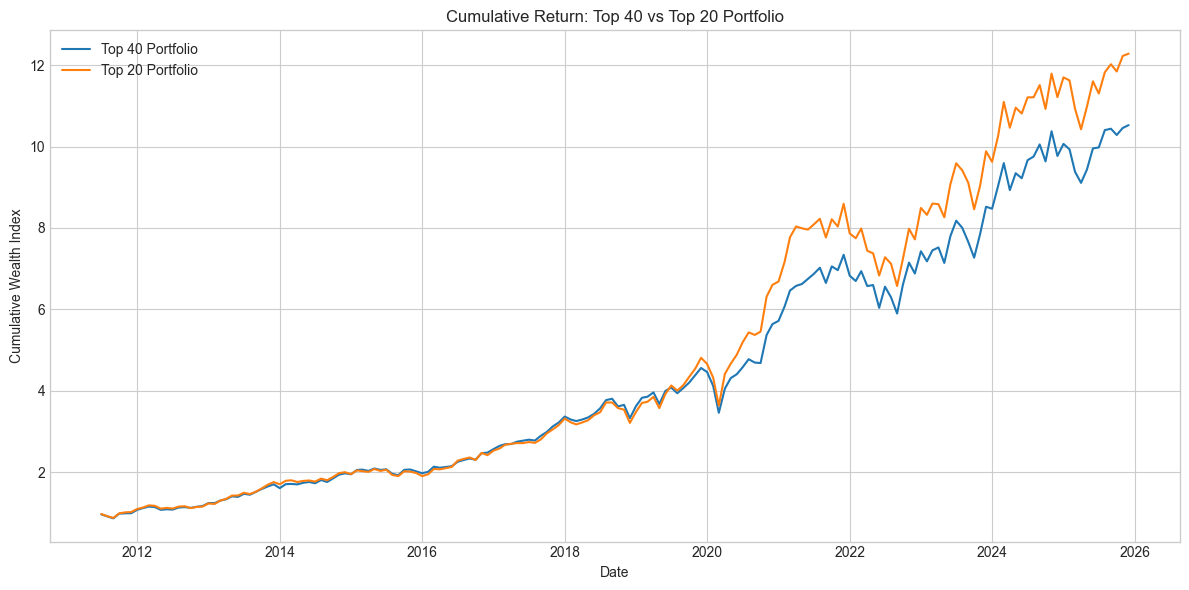

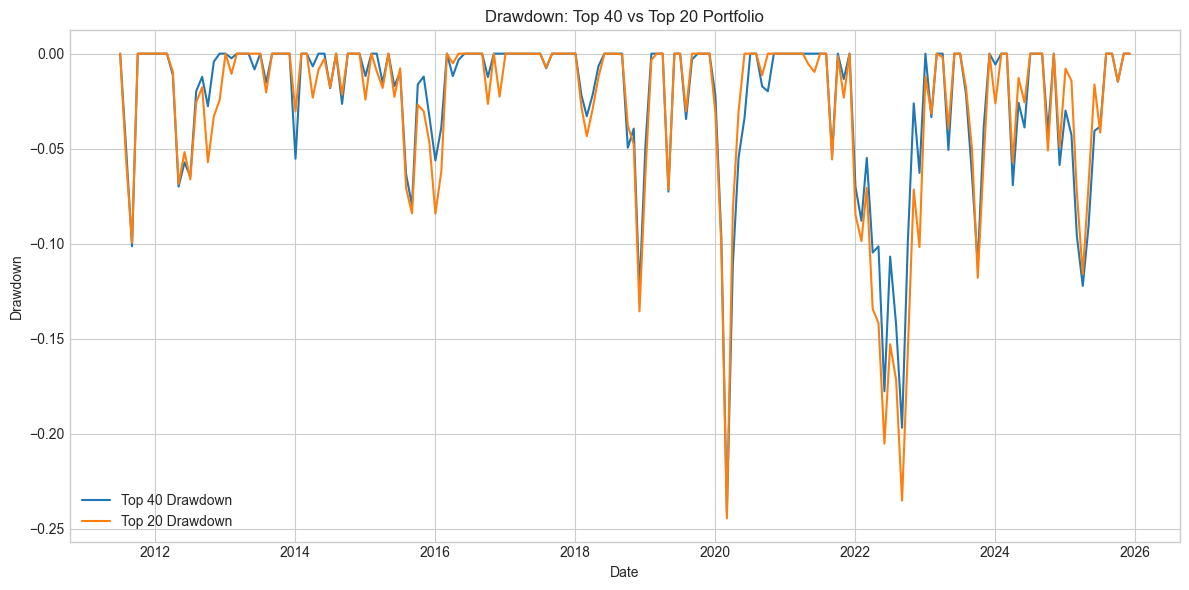

Saved final portfolio return file.


In [34]:
# ------------------------------------------------------------
# 10.7 Plot cumulative wealth index
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

# Plot cumulative wealth index for Top 40 and Top 20 portfolios
plt.plot(
    portfolio_returns["month"],
    portfolio_returns["top40_cumulative"],
    label="Top 40 Portfolio"
)
plt.plot(
    portfolio_returns["month"],
    portfolio_returns["top20_cumulative"],
    label="Top 20 Portfolio"
)

plt.title("Cumulative Return: Top 40 vs Top 20 Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
# Save the cumulative return plot
plt.savefig("data/cumulative_return_top40_top20.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 10.8 Plot drawdown chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

# Plot drawdown for Top 40 and Top 20 portfolios
plt.plot(
    portfolio_returns["month"],
    portfolio_returns["top40_drawdown"],
    label="Top 40 Drawdown"
)
plt.plot(
    portfolio_returns["month"],
    portfolio_returns["top20_drawdown"],
    label="Top 20 Drawdown"
)

plt.title("Drawdown: Top 40 vs Top 20 Portfolio")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
# Save the drawdown plot
plt.savefig("data/drawdown_top40_top20.png", dpi=300)
plt.show()

# Save final portfolio return result
portfolio_returns.to_csv("data/final_portfolio_returns_with_performance.csv", index=False)
print("Saved final portfolio return file.")

### 11.
### 12.
### 
### 
### 
### 
### 
### 
### 
### 
